# <a href="https://thetahat.ru/courses/ad">Введение в анализ данных</a>
## Домашнее задание 1. Простой анализ данных.


**Правила, <font color="red">прочитайте внимательно</font>:**

* Выполненную работу нужно отправить телеграм-боту `@thetahat_ds25_bot`. Для начала работы с ботом каждый раз отправляйте `/start`. Дождитесь подтверждения от бота, что он принял файл. Если подтверждения нет, то что-то не так. **Работы, присланные иным способом, не принимаются.**
* Дедлайн см. в боте. После дедлайна работы не принимаются кроме случаев наличия уважительной причины.
* Прислать нужно **ноутбук в формате `ipynb`**. Если вы строите интерактивные графики, их стоит прислать в формате html.
* Следите за размером файлов. **Бот не может принимать файлы весом более 20 Мб.** Если файл получается больше, заранее разделите его на несколько.
* Выполнять задание необходимо полностью самостоятельно. **При обнаружении списывания всем участникам списывания дается штраф -2 балла к итоговой оценке за семестр.**
* Решения, размещенные на каких-либо интернет-ресурсах, не принимаются. Кроме того, публикация решения в открытом доступе может быть приравнена к предоставлении возможности списать.
* Обратите внимание на <a href="https://thetahat.ru/courses/ai-rules"><b>правила использования ИИ-инструментов</b></a> при решении домашнего задания.
* **Код из рассказанных на занятиях ноутбуков** можно использовать без ограничений.
* Для выполнения задания используйте этот ноутбук в качестве основы, ничего не удаляя из него. Можно добавлять необходимое количество ячеек.
* Комментарии к решению пишите в markdown-ячейках.
* Выполнение задания (ход решения, выводы и пр.) должно быть осуществлено на русском языке.
* Решение проверяется системой ИИ-проверки <a href="https://thetahat.ru/"><img src="attachment:ai_eval_small.png" style="display: inline; vertical-align: middle;"></a> **ThetaGrader**. Результат проверки валидируется и исправляется человеком, после чего комментарии отправляются студентам.
* Если код будет не понятен проверяющему, оценка может быть снижена.
* Никакой код из данного задания при проверке запускаться не будет. *Если код студента не выполнен, недописан и т.д., то он не оценивается.*

<b><font size="5" color="red">Важно!!! Правила заполнения ноутбука:</font></b>
* Запрещается удалять имеющиеся в ноутбуке ячейки, менять местами положения задач.
* Сохраняйте естественный линейный порядок повествования в ноутбуке сверху-вниз.
* Отвечайте на вопросы, а также добавляйте новые ячейки в предложенных местах, которые обозначены `<...>`.
* В markdown-ячейка, содержащих описание задачи, находятся специальные отметки, которые <font color="red"><b>запрещается модифицировать</b></font>.
* При нарушении данных правил работа может получить 0 баллов.


**Перед выполнением задания посмотрите презентацию по выполнению и оформлению домашних заданий с занятия 2.**


**Баллы за задание:**

<b><font color="blue">Легкая часть</font></b> (достаточно на "хор"):
* Задача 1 &mdash; 30 баллов
* Задача 2 &mdash; 90 баллов

Баллы учитываются в <b>обязательной части</b> курса и не влияют на оценку по факультативной части.

In [22]:
# Bot check

# HW_ID: fpmi_ad1
# Бот проверит этот ID и предупредит, если случайно сдать что-то не то

# Status: final
# Перед отправкой в финальном решении удали "not" в строчке выше
# Так бот проверит, что ты отправляешь финальную версию, а не промежуточную

#### Тренировочные задачи на библиотеки

Если вы неуверенно себя чувствуете в библиотеках numpy, pandas, matplotlib, seaborn, рекомендуем сначала
* посмотреть материалы по библиотекам на нашем сайте
* прорешать упражнения на библиотеки на странице курса
* прорешать <a href="https://contest.yandex.ru/contest/75090/enter/">два упражнения на numpy</a> в системе Яндекс.Контест.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 9ede240862d9bf1602556040405c317e -->
---
### <font color="blue"><i>Легкая часть</i></font>

### Задача 1

На семинаре мы разбирали классификацию изображений на основе kNN. В этом задании мы вернемся к датасету [MNIST](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html) и попробуем улучшить результат, полученный на семинаре.

Для начала, загрузите данные и разделите их на обучающую и тестовую части.

Импортируем все необходимые библиотеки

In [ ]:
!pip install scikit-learn
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

random_state = 42

Загружаем данные

In [ ]:
digits = datasets.load_digits()
n_samples = len(digits["images"])

Делим их на две части

In [ ]:
X, y = digits["images"].reshape(n_samples, -1), digits["target"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, train_size=0.7, random_state=random_state
)

Число соседей в модели kNN является необучаемым параметром т.е. гиперпараметром который выставляется вручную. Как мы видели на лекции, выбор оптимального значения $k$ важен, так как слишком маленькое значение может привести к переобучению, а слишком большое — к недообучению.

Постройте график зависимости точности (`accuracy_score`) предсказания kNN от значения $k$ (от 1 до 20) для обучающей и тестовой выборок.

Считаем метрику Accuracy в зависимости от k

In [ ]:
train_accuracy = []
test_accuracy = []

k_values = range(1, 21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, algorithm="brute")
    model.fit(X_train, y_train)
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    train_accuracy.append(accuracy_score(y_train, y_train_pred))
    test_accuracy.append(accuracy_score(y_test, y_test_pred))

Строим графики по полученным значениям

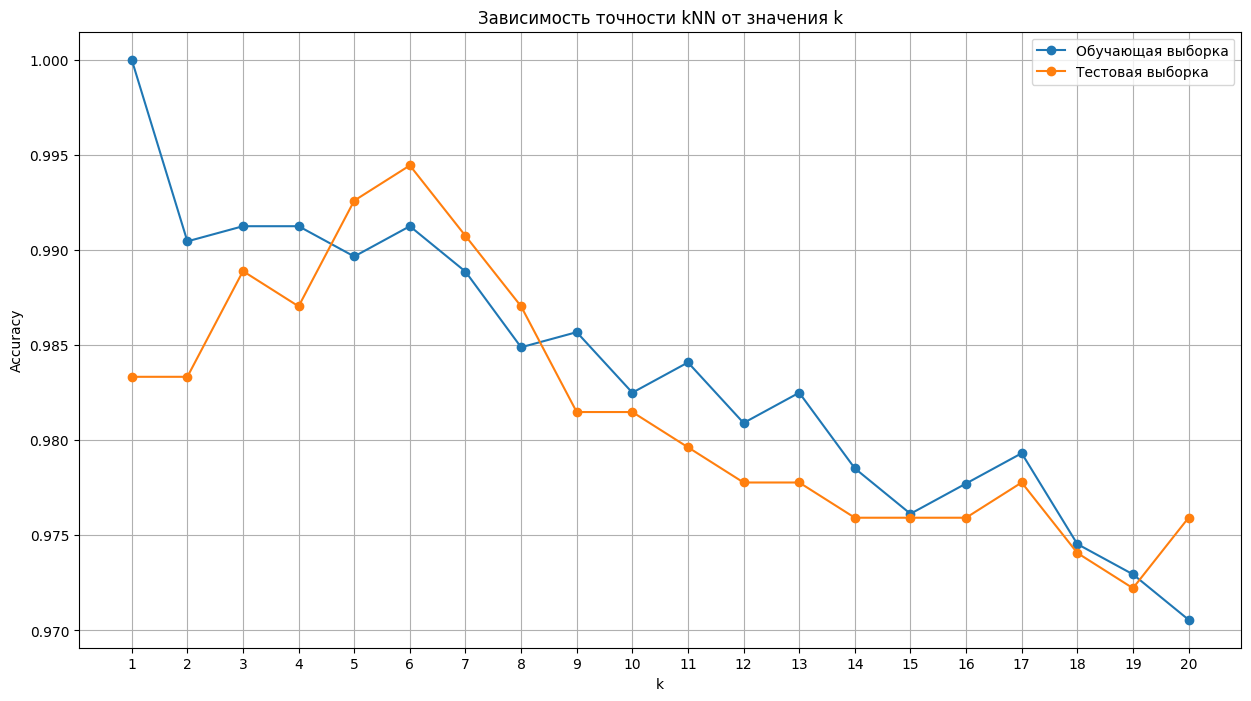

In [ ]:
plt.figure(figsize=(15, 8))
plt.plot(k_values, train_accuracy, label="Обучающая выборка", marker="o")
plt.plot(k_values, test_accuracy, label="Тестовая выборка", marker="o")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Зависимость точности kNN от значения k")
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- fe9171a6e245a953987df27f018c61c2 -->
&#x2753; **Вопрос** &#x2753;

> Почему при $k = 1$ на тренировочной выборке метрика качества составляет 100%.

**Ваш ответ:** Потому что тогда кNN как ближайшего соседа всегда будет брать сам себя.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- cdb15caec1719ca7ba80d25b716879ca -->
Помимо числа соседей гиперпараметром модели также является *метрика расстояния* между объектами.

> По умолчанию используется *Евклидова метрика* ($L_2$), согласно которой расстояние между двумя точками $x_1 =(x_{11}, …, x_{1d})$ и $x_2=(x_{21},…,x_{2n})$ в $d$-мерном пространстве определяется как:
$$\rho(x_1, x_2) = \sqrt{\sum^d_{j=1}\left(x_{1j} - x_{2j}\right)^2}.$$
>
> Иногда в kNN имеет смысл использовать другие метрики, например *метрику Манхэттена* ($L_1$).
$$\rho(x_1, x_2) = \sum^d_{j=1} \left|x_{1j} - x_{2j}\right|.$$
>
> Выбор одной из них зависит от особенностей задачи и данных. В частности,
>
> * метрика Манхэттена менее чувствительна к выбросам, чем евклидово расстояние, что делает её полезной для данных с сильным шумом или при наличии аномалий;
>
> * в задачах с разреженными данными (например, текстовые данные, представленные в виде векторов) метрика Манхэттена может работать лучше, чем евклидово расстояние.

Проведите аналогичный эксперимент используя в качестве гиперпараметра $L_1$-метрику (выясните сами, как ее задать). Выведите на одном графике зависимости точности (accuracy) от значения $k$ для обучающей и тестовой выборок для обоих метрик.

Считаем метрику Accuracy в зависимости от k

In [ ]:
train_accuracy_l1 = []
test_accuracy_l1 = []
train_accuracy_l2 = []
test_accuracy_l2 = []

k_values = range(1, 21)

for k in k_values:
    model_l1 = KNeighborsClassifier(n_neighbors=k, p=1, algorithm="brute")
    model_l1.fit(X_train, y_train)

    y_train_pred_l1 = model_l1.predict(X_train)
    y_test_pred_l1 = model_l1.predict(X_test)


    train_accuracy_l1.append(accuracy_score(y_train, y_train_pred_l1))
    test_accuracy_l1.append(accuracy_score(y_test, y_test_pred_l1))


    model_l2 = KNeighborsClassifier(n_neighbors=k, p=2, algorithm="brute")
    model_l2.fit(X_train, y_train)


    y_train_pred_l2 = model_l2.predict(X_train)
    y_test_pred_l2 = model_l2.predict(X_test)


    train_accuracy_l2.append(accuracy_score(y_train, y_train_pred_l2))
    test_accuracy_l2.append(accuracy_score(y_test, y_test_pred_l2))

Строим графики по полученным значениям

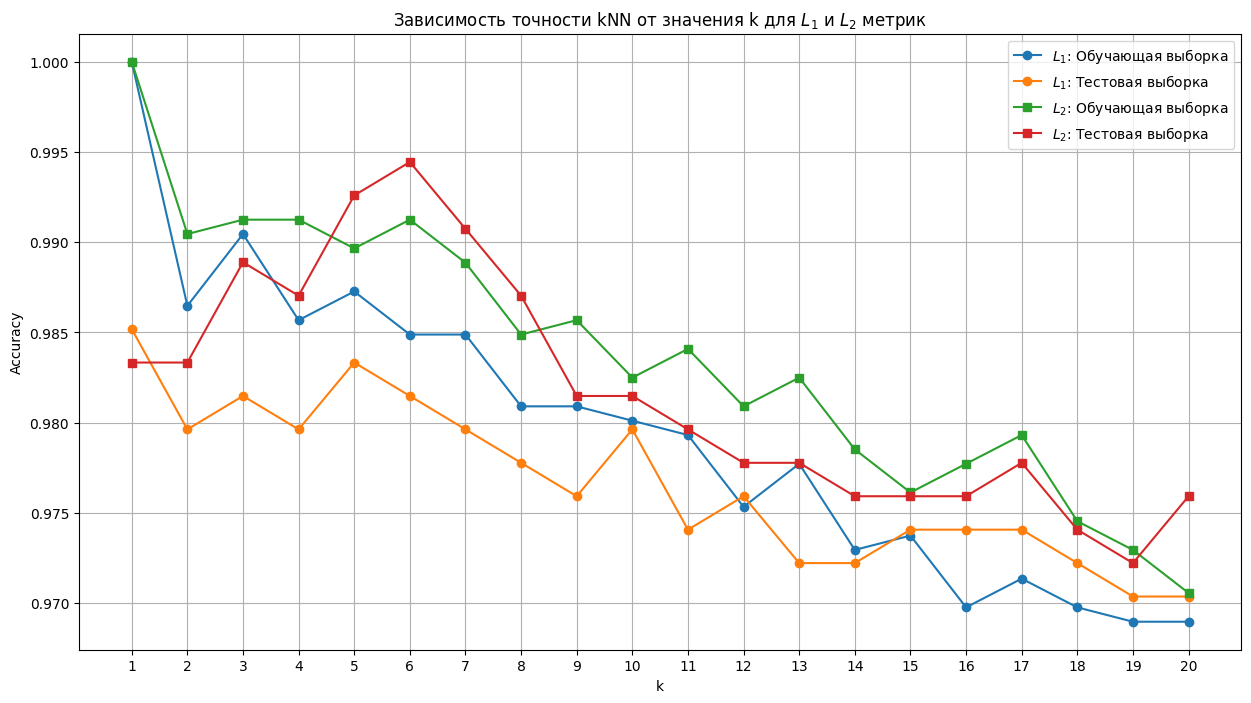

In [ ]:
plt.figure(figsize=(15, 8))

plt.plot(k_values, train_accuracy_l1, label="$L_1$: Обучающая выборка", marker="o",)
plt.plot(k_values, test_accuracy_l1, label="$L_1$: Тестовая выборка", marker="o")

plt.plot(k_values, train_accuracy_l2, label="$L_2$: Обучающая выборка", marker="s")
plt.plot(k_values, test_accuracy_l2, label="$L_2$: Тестовая выборка", marker="s")

plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Зависимость точности kNN от значения k для $L_1$ и $L_2$ метрик")
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()

&#x2754; **Вопрос** &#x2754;

> Как вы думаете почему смена метрики так сильно повлияла на характер кривых?

**Ваш ответ:** Из полученных кривых видно, что метрика $L_1$ проигрывает метрике $L_2$ на соответствующих выборках. Возможная причина в том, что метрика $L_1$ слабее реагирует на выбросы, т.к. в ней суммируются не квадраты а модули разности координат, соответственно при явном несовпадении нескольких пикселей одного изображения с другим, метрика $L_1$ отреагирует не так сильно, как метрика $L_2$, из-за чего возможно ложное срабатывание.

**Выводы:** В этом задании мы познакомились с моделью kNN и попробовали улучшить результат ее работы в сравнении с семинаром. Сравнили влияние выбора метрик($L_1$ и $L_2$) на результат работы модели и воспользовались метрикой Accuracy для оценки качества полученной модели.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 00000000000000000000000000000000 -->


---

### Задача 2

Перед выполнением задачи рекомендуется посмотреть <a href="https://thetahat.ru/courses/ad/main/1/main_sem_kNN">материал</a> с семинара.

#### 0. Подготовка данных

Титаник был крупнейшим пассажирским судном в 1912—1913 годах. Во время первого рейса затонул в северной Атлантике, столкнувшись с айсбергом в ночь с 14 на 15 апреля 1912 года, при этом погибло 1502 из 2224 пассажиров и членов экипажа. Данные о пассажирах были собраны в таблицы, которые можно скачать с <a href="https://www.kaggle.com/c/titanic/data" target="_blank">Kaggle</a>. Эти данные часто используются в качестве обучающих в анализе данных.


Загрузите данные с помощью `pandas`.

Импортируем все необходимы библиотеки

In [6]:
!pip install scikit-learn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

random_state = 42

In [7]:
titanic = pd.read_csv("train.csv")
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


Для лучшего понимания процесса работы с данными, уточним ключевые термины.

> **Объект** — это единица данных, представленная набором признаков и используемая для обучения или предсказаний модели. В данной задаче являются пассажиры, им соответствуют *строки* таблицы данных.
>
> **Признаки (features)** — это характеристики, которые описывают объекты в данных. В таблицах данных они обычно соответствуют *колонкам*. В данной задаче мы будем работать со следующими признаками
>
> * `Pclass` — класс билета (1 = первый класс, 2 = второй класс, 3 = третий класс);
>
> * `Age` — возраст пассажира;
>
> * `SibSp` — количество братьев, сестер или супругов на борту;
>
> * `Parch` — количество родителей или детей на борту;
>
> * `Fare` — стоимость билета.
>
> **Таргет (target)** — это целевая переменная, которую мы хотим предсказать. В данной задаче мы будем предсказывать `Survived` — бинарная переменная, указывающая, выжил ли пассажир (1) или нет (0). Значения этой переменной имеются для обучающего набора данных, а для тестого — нет.

Из каждой части оставим несколько признаков, с которыми мы будем работать, а также отдельно &mdash; целевой признак, который мы хотим предсказать.

In [4]:
features_columns = ["Pclass", "Age", "Sex", "SibSp", "Parch", "Fare"]
target_column = "Survived"  # Целевой признак

X, y = titanic[features_columns], titanic[target_column]

NameError: name 'titanic' is not defined

В данных могут присутствовать пропуски. Пока что мы не умеем с ними работать, так что исключим из данных.

Посмотрите, сколько объектов имеют хотя бы один пропуск. Удалите их из данных.

Кол-во пропусков

In [ ]:
num_rows_with_nan = X.isna().any(axis=1).sum()
print(f"Количество строк с пропусками: {num_rows_with_nan}")

Количество строк с пропусками: 177


Чистим данные

In [ ]:
X_cleared = X.dropna()
y_cleared = y[X_cleared.index]

Разделите данные по строкам на две части случайным образом в соотношении 7:3. Первую часть мы будем называть *обучающей*, а вторую &mdash; *тестовой*.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_cleared, y_cleared, test_size=0.3, random_state=random_state)

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 371b31e8ca86989a98cce342afcbbf2a -->
#### 1. Исследование

> &#x2757; **Внимание.** Эта часть задачи должна выполняться *исключительно на обучающих данных*. За использование тестовых данных решение не будет оценено.

Проведите визуальный анализ данных чтобы понять, как различные признаки влияют на целевой. Исследовать можно не целиком обучающие данные, а разделить их на две части по одному из признаков, а далее рассматривать каждую часть отдельно.

*Не забывайте про информативность и эстетичность графиков, посмотрите презентацию про оформление домашних заданий.*

Сначала создадим новый DataFrame, который содержит и признаки, и целевую переменную.

In [ ]:
data = X_train.copy()
data['Survived'] = y_train

Определим корреляцию целевого признака с другими.

Для начала посмотрим на пол человека.

In [ ]:
survived_men = data[(data['Sex'] == 'male') & (data['Survived'] == 1)]['Survived'].sum()
men_count = len(data[data['Sex'] == 'male'])
survived_women = data[(data['Sex'] == 'female') & (data['Survived'] == 1)]['Survived'].sum()
women_count = len(data[data['Sex'] == 'female'])

proportion_women_men_survived = ((survived_women / women_count) / (survived_men / men_count))

print(f"Отношение доли выживших женщин к доле выживших мужчин: {proportion_women_men_survived:.2f}")

Отношение доли выживших женщин к доле выживших мужчин: 3.92


Из данного соотношения видно, что доля выживших женщин превыщает долю выживших мужчин в почти 4 раза, что может свидетельствовать о корреляции между этими признаками.
Это так же отражает гистограмма:

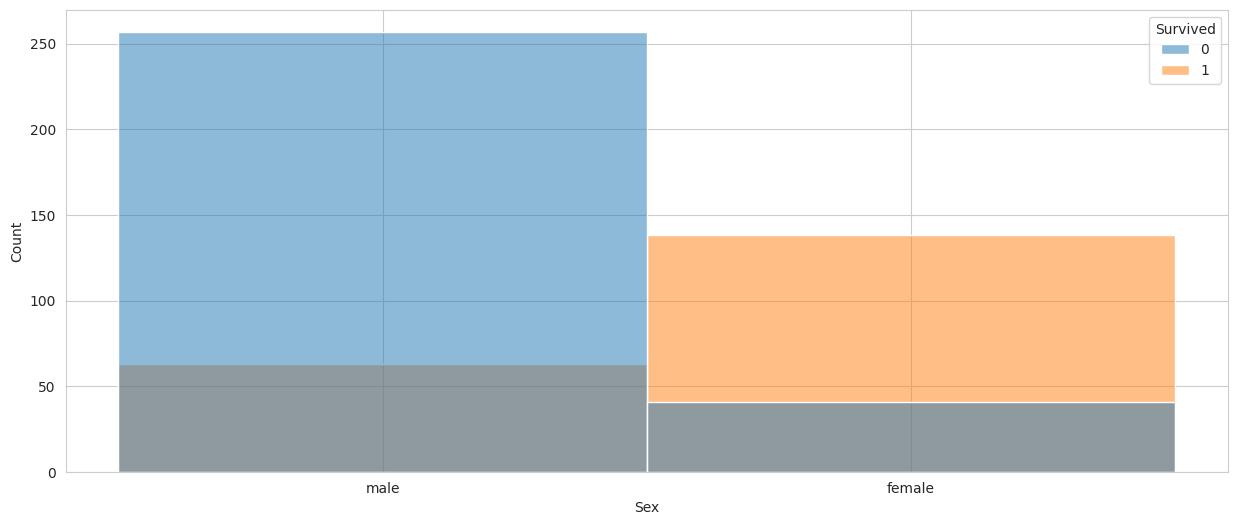

In [ ]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15, 6))
    sns.histplot(data=data, x='Sex', hue='Survived')

Теперь попробуем найти остальные зависимости.

Посмотрим на стоимость билетов пассажиров:

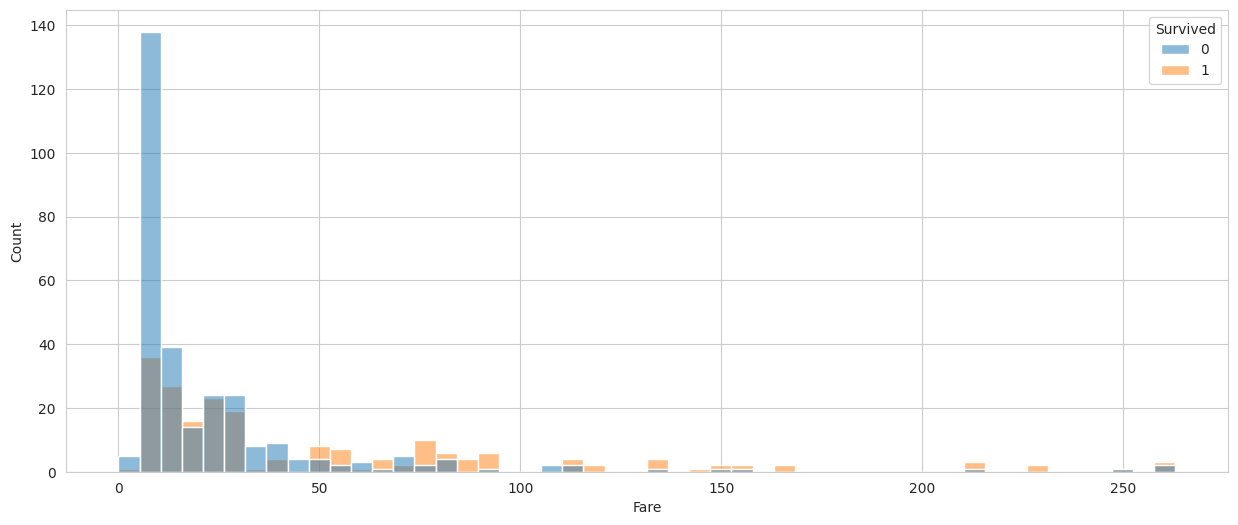

In [ ]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15, 6))
    sns.histplot(data=data, x='Fare', bins=50, hue='Survived')

Видно, что при цене билета ниже 50 доля смертей выше чем доля выживших людей, это можно учесть при дальнейшем анализе данных

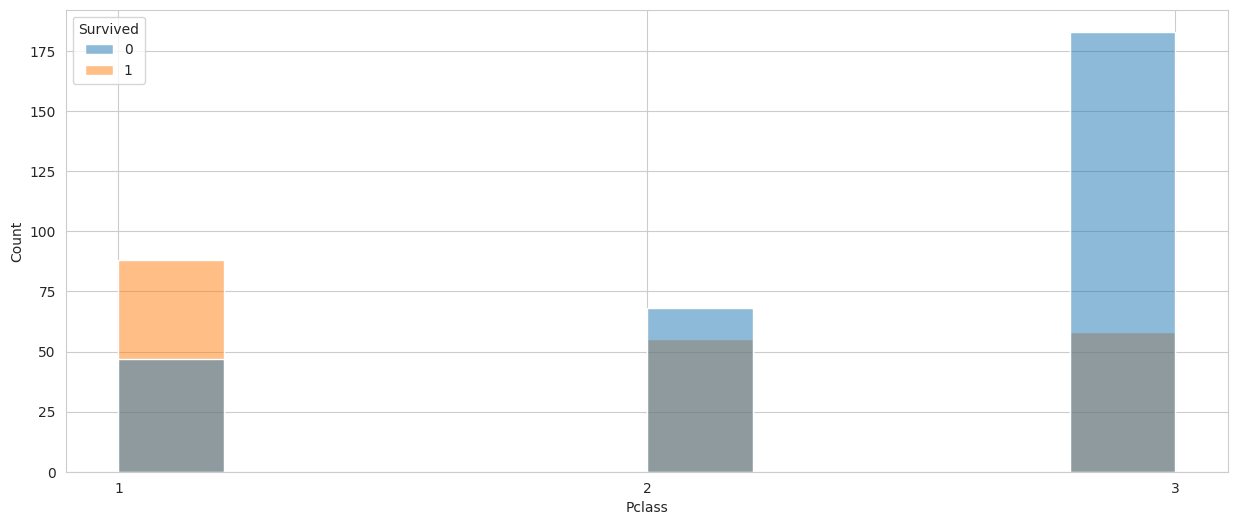

In [ ]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15, 6))
    sns.histplot(data=data, x='Pclass', hue='Survived')
    plt.xticks([1, 2, 3])

Так же видно, что пассажиры пребывающие в дешевых классах(не в 1-ом) так же имеют большую долю смертей

В гистограмме возрастов, представленной ниже зависимостей не наблюдается(Кроме, возможно того, что дети возрастом меньше 5 лет имеют высокий показатель выживаемости)

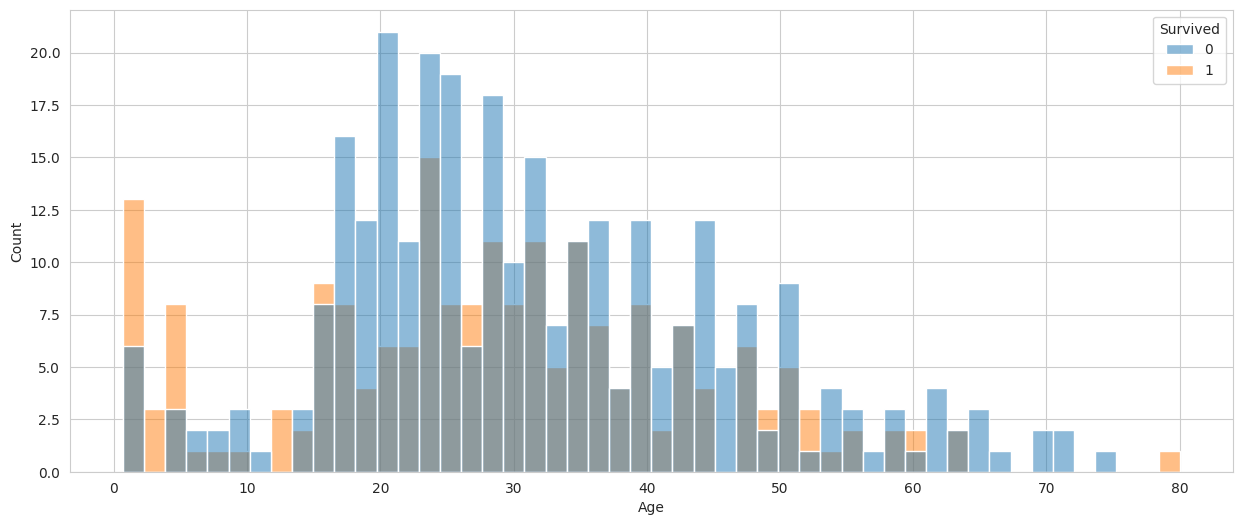

In [ ]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15, 6))
    sns.histplot(data=data, x='Age', bins=50, hue='Survived')

На двух гистограммах ниже (для SibSp и для Parch) зависимости не наблюдается.

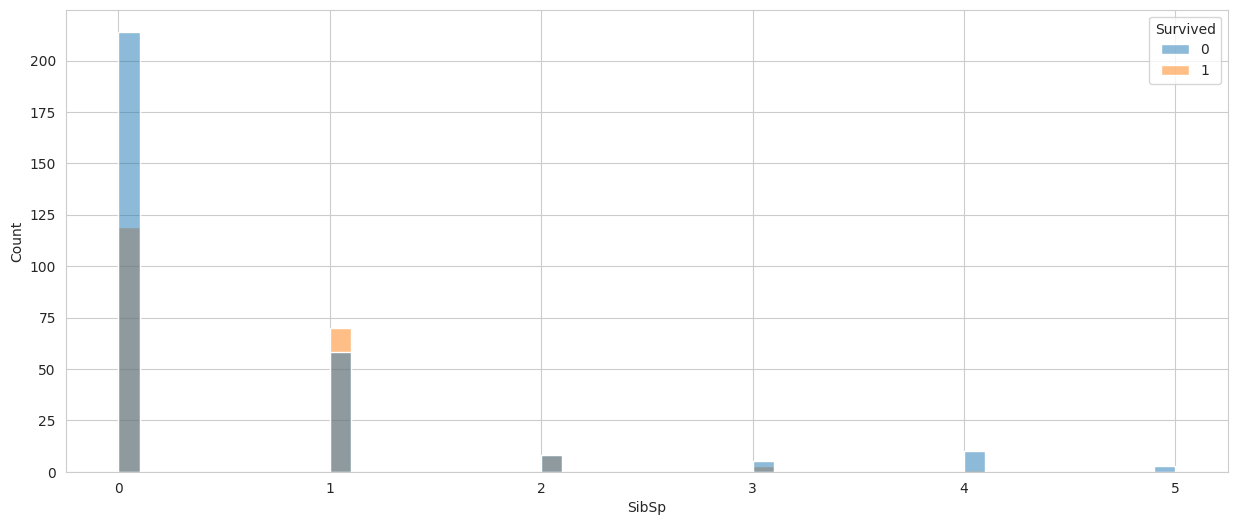

In [ ]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15, 6))
    sns.histplot(data=data, x='SibSp', bins=50, hue='Survived')

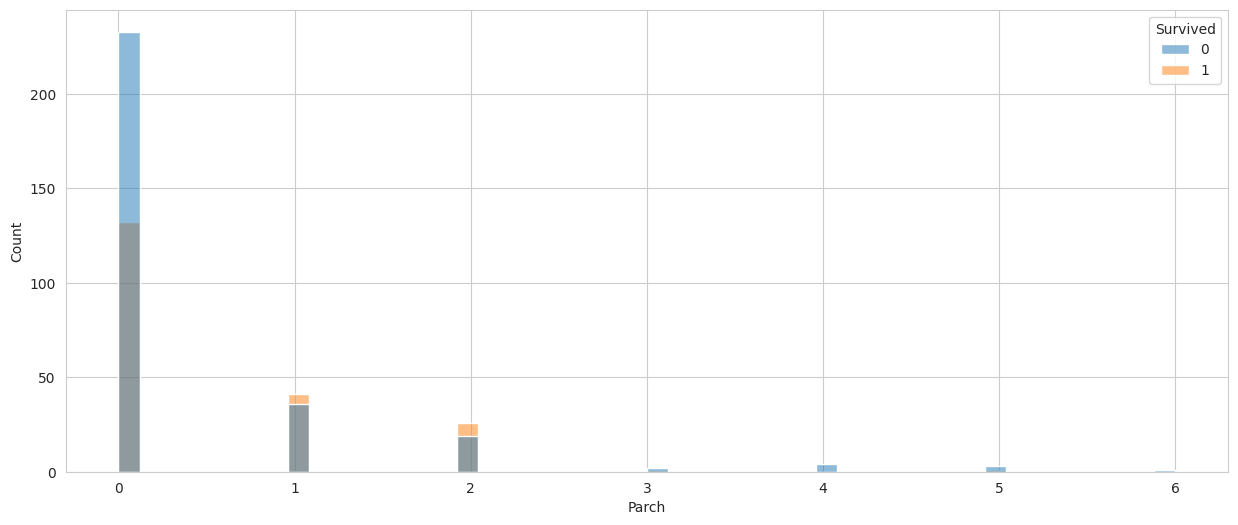

In [ ]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15, 6))
    sns.histplot(data=data, x='Parch', bins=50, hue='Survived')

Попробуем более точно просмотреть корреляцию денежного достатка и выживаемости.
Разобьем данные на две части, в одной класс пассажира будет 1, в другой 2 и 3. Посмотрим на зависимость выживаемости от возраста для этих двух групп

In [ ]:
data_first = data[data["Pclass"] == 1]
data_second = data[data["Pclass"] > 1]

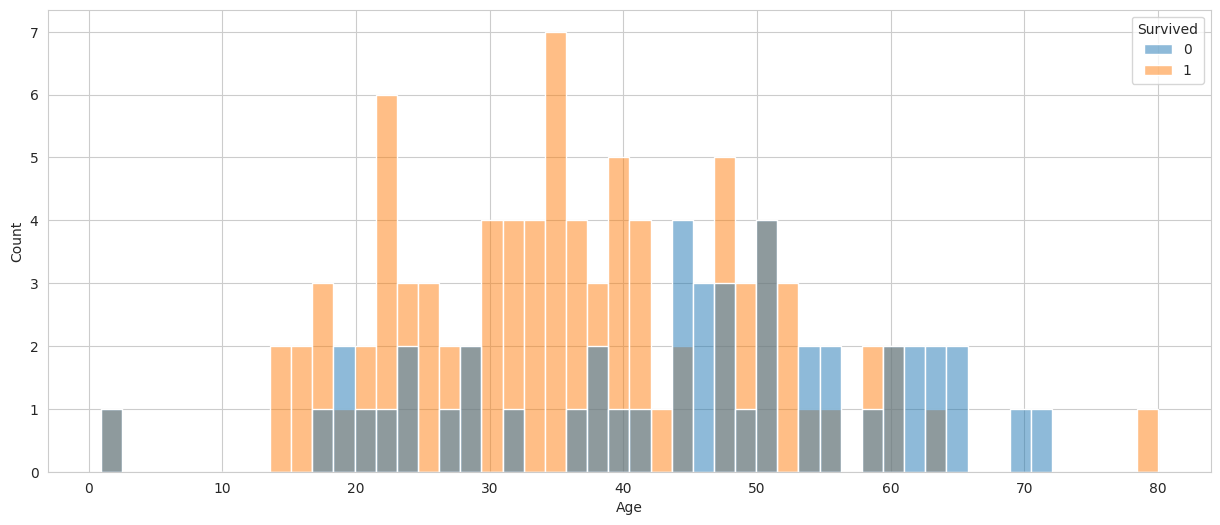

In [ ]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15, 6))
    sns.histplot(data=data_first, x='Age', bins=50, hue='Survived')

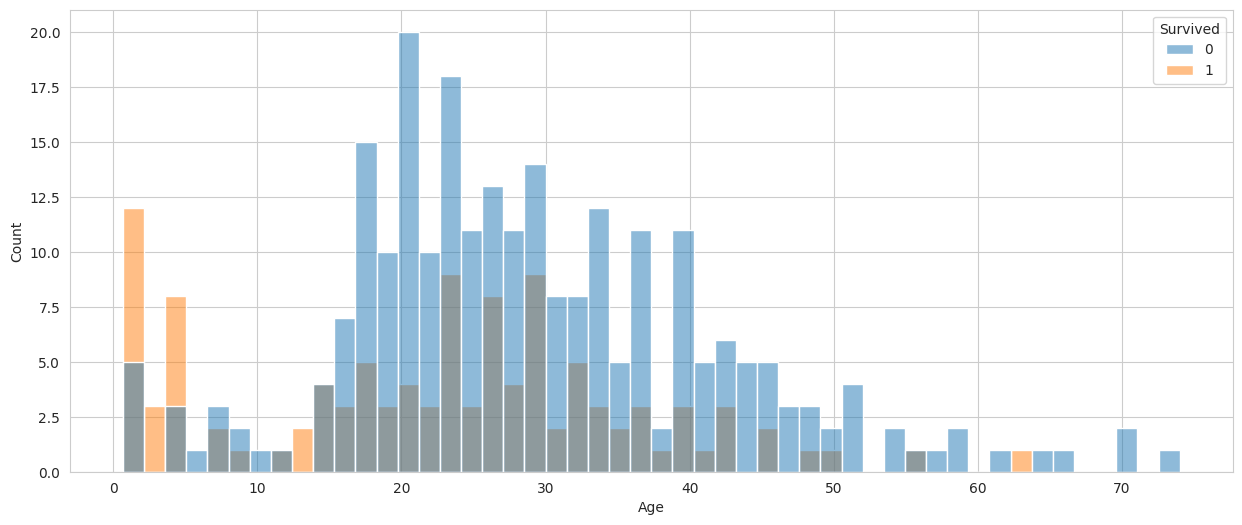

In [ ]:
with sns.axes_style('whitegrid'):
    plt.figure(figsize=(15, 6))
    sns.histplot(data=data_second, x='Age', bins=50, hue='Survived')

Видно, что ниже 5 лет выживаемость выскоая даже у второй группы людей. Отсюда можно построить два дерева(учитывая то, что Pclass и Fare тесно связаны, поэтому разбивая данные по Pclass можно игнорировать Fare).

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 476dce11b8cac8705a10bff695e4cdee -->
#### 2. Классификация логическими правилами

На основе выше проведенного исследования предложите два разных правила в виде решающего дерева, пример которого можете посмотреть в презентации с первой лекции (классификация котиков). Никакие статистические методы использовать не требуется, только логику и графики. Любые решения "из коробки" использовать запрещено. Например, достаточно пояснения "*по графику (описание графика) визуально я увидел, что при X > 100 большинство пассажиров выжило, поэтому использую правило (описание правила)*".

В данной задаче достаточно, если первое дерево будет иметь максимальную глубину 2, а второе &mdash; глубину 1, и при этом не является поддеревом первого. Дерево из одного листа имеет глубину 0.

*Указание*. Попросите ИИ красиво оформить описание дерева и его пояснение.

**Дерево 1:**
Предсказание на основе признака Sex
Описание:
Это дерево решений использует только один признак — пол пассажира (Sex). Оно принимает решение следующим образом:

Если пассажир — женщина (Sex == 'female'), то он выживает (1).

Если пассажир — мужчина (Sex == 'male'), то он не выживает (0).

**Логика**:
Простое правило, основанное на исторических данных, что женщины и дети имели приоритет при спасении на Титанике.

Дерево не учитывает другие признаки, такие как возраст, класс каюты и т.д.

**Дерево 2:**
Предсказание на основе признаков Pclass и Age
Описание:
Это дерево решений использует два признака — класс каюты (Pclass) и возраст (Age). Оно принимает решение следующим образом:

Если пассажир принадлежит к первому классу (Pclass == 1), то он выживает (1).

Если пассажир принадлежит ко второму или третьему классу (Pclass > 1):

Если возраст пассажира меньше 6 лет (Age < 6), то он выживает (1).

Иначе пассажир не выживает (0).

**Логика**:
Пассажиры первого класса имели приоритет при спасении.

Дети младше 6 лет также имели высокие шансы на выживание, независимо от класса(как и женщины).

In [ ]:
def tree_v1(features: pd.DataFrame) -> pd.Series:
    predicted = features['Sex'].apply(lambda x: 1 if x == 'female' else 0)

    return predicted

In [ ]:
def tree_v2(features: pd.DataFrame) -> pd.Series:
    predicted = features.apply(
        lambda row: 1 if row['Pclass'] == 1 else (1 if row['Age'] < 6 else 0),
        axis=1
    )
    return predicted

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 509cca15393d5b0fb3cf40b463d12077 -->
Проверьте работоспособность данных моделей на тестовой выборке и оцените качество модели по метрике `accuracy`.

> &#x2755; *Примечание.* Полученные значения не влияют на оценку по заданию. Оценивается только корректность и обоснованность решения, а также графики и выводы.

In [ ]:
import pandas as pd

def accuracy(target: pd.Series, predicted: pd.Series) -> float:
    correct_predictions = (target == predicted).sum()
    acc = correct_predictions / len(target)
    return acc

Предсказания на основе 1-го дерева:

In [ ]:
y_pred = tree_v1(X_test)
accuracy(y_test, y_pred)

0.7534883720930232

Предсказания на основе второго дерева:

In [ ]:
y_pred = tree_v2(X_test)
accuracy(y_test, y_pred)

0.6744186046511628

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 2bf781f25f8969f7e712ea5d28d608a3 -->
#### 3. Классификация методом ближайшего соседа

В данной части задачи оставим только признаки `'Pclass'`, `'Age'`, `'Sex'`,`'Fare'`.


&#x2753; **Вопрос** &#x2753;
> Какие могли бы возникнуть проблемы при использовании признаков `'SibSp'`, `'Parch'`? Имеется ли подобная проблема для признака `'Pclass'`?

**Ваш ответ:** при использовании этих признаков влияние на данные одной семьи увеличивается экспоненциально в зависимости от значения признака(то есть если если у ребенка есть родитель, то и у родителя есть ребенок и оба пассажира попадают в одну категорию по признаку). Получается ситуация, в которой одна "большая семья" может сильно искажать данные.

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 3bfbe10cf933e1302c2f524a99acfa54 -->
Постройте классификатор методом ближайшего соседа. Обучите его и оцените качество модели. Сравните с предыдущим методом.

Пока никаких преобразований данных делать не нужно.




Выделим целевой признак и оставим только 4 выбранных нами признака

In [8]:
features_columns = ["Pclass", "Age", "Sex", "Fare"]
target_column = "Survived"

X, y = titanic[features_columns], titanic[target_column]

Посмотрим на кол-во строк с пропусками и удалим их

In [9]:
num_rows_with_nan = X.isna().any(axis=1).sum()
print(f"Количество строк с пропусками: {num_rows_with_nan}")

Количество строк с пропусками: 177


In [10]:
X_cleared = X.dropna()
y_cleared = y[X_cleared.index]

Так же для модели kNN преобразуем male и female в вещественный тип

In [11]:
X_cleared.loc[:, 'Sex'] = X_cleared['Sex'].map({'male': 0, 'female': 1})

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X_cleared, y_cleared, test_size=0.3, random_state=random_state)

Теперь обучим kNN

In [ ]:
test_accuracy = []

k_values = range(1, 25)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, algorithm="brute")
    model.fit(X_train, y_train)
    y_test_pred = model.predict(X_test)
    test_accuracy.append(accuracy_score(y_test, y_test_pred))

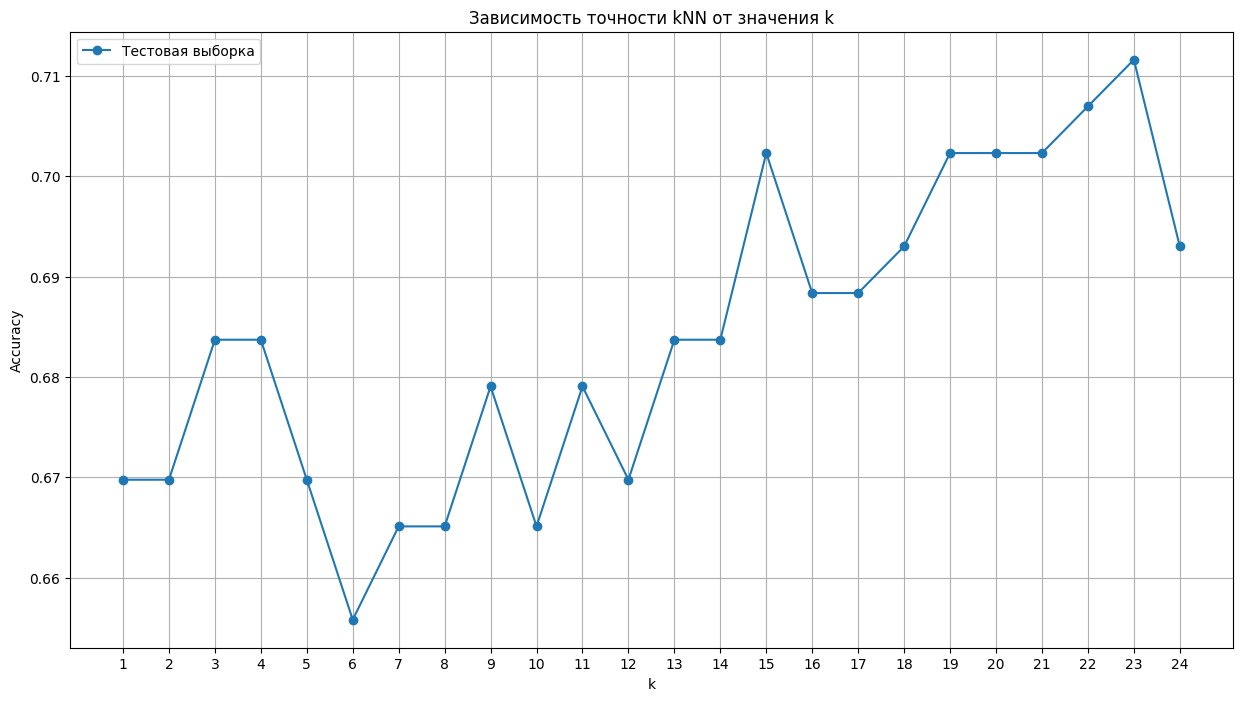

In [ ]:
plt.figure(figsize=(15, 8))
plt.plot(k_values, test_accuracy, label="Тестовая выборка", marker="o")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Зависимость точности kNN от значения k")
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()

Видно, что результат проигрывает обычному классифицированию по полу, что делает(пока что) этот метод плохим для анализа

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 21227e76b996f62c6c83ee38ce486bdf -->
Попробуем улучшить результаты предсказаний, для этого надо сначала посмотреть на сами данные. Выведите значение минимального и максимального объекта для каждого признака.

In [13]:
for column in X_train.columns:
    min_value = X_train[column].min()
    max_value = X_train[column].max()
    print(f"Признак '{column}': min = {min_value}, max = {max_value}")

Признак 'Pclass': min = 1, max = 3
Признак 'Age': min = 0.67, max = 80.0
Признак 'Sex': min = 0, max = 1
Признак 'Fare': min = 0.0, max = 263.0


Как мы видим данные в каждом столбце распределены очень по-разному.

&#x2753; **Вопрос** &#x2753;
> Как это может повлиять на работу kNN, почему?

**Ваш ответ:**  Если не нормировать данные, один признак, значения которого на порядок больше других, будет влиять на данные сильнее. (Соседей будут отбирать практически по нему)


Для решения этой проблемы нужно привести признаки к единому масштабу. Существует много методов масштабирования рассмотрим работу одного из них &mdash; **минимаксная нормализация**

  
> **Минимакс** &mdash; линейное преобразование данных в диапазоне $[0, 1]$, где минимальное и максимальное масштабируемые значения соответствуют 0 и 1 соответственно.
> Реализуется оно по следующей формуле:
>
> $$\widetilde{x}_{ij} = \frac{x_{ij} - m_j}{M_j - m_j}$$
>
> где $x_{ij}$ &mdash; значение признака $j$ для объекта $i$, а $m_j$ и $M_j$ &mdash; минимальное и максимальное значения признака $j$ в обучающем наборе данных.  
> В модуле `sklearn.preprocessing` есть [класс](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html) `MinMaxScaler`, который реализует эту операцию. Давайте рассмотрим методы этого класса подробнее:
>
> * `fit(X)`: вычисляет минимальные и максимальные значения для каждого признака.
>
> * `transform(X)`: применяет масштабирование к данным.
>
> * `fit_transform(X)`: объединяет оба метода, сначала подгоняя модель, а затем трансформируя данные.
>
> * `inverse_transform(X)`: восстанавливает исходные данные из масштабированных.


Стоит отметить что существуют и другие методы масштабирования данных.

&#x2753; **Вопрос** &#x2753;
> В чем может быть недостаток такого метода масштабирования?

**Ваш ответ:** Если в наборе данных присутствуют экстремальные значения (например, очень большие или очень маленькие числа, которые являются аномалиями), разность минимального и максимального значения для признака становится очень большой. В результате большинство значений после нормализации "сжимаются" в узкий интервал ближе к 0 или 1, что может ухудшить различия между нормальными значениями и повлиять на качество работы модели машинного обучения.


<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 3cf8b0b6b0402c9ceb439c2de6ee4276 -->


Отмасштабируйте данные

Добавим необходимый класс для реализации *минимаксной нормализации*

In [14]:
from sklearn.preprocessing import MinMaxScaler

Нормируем даннные

In [16]:
scaler = MinMaxScaler()
X_scaled_train = scaler.fit_transform(X_train)
X_scales_test = scaler.transform(X_test)

Приводим данные обратно к типу DataFrame

In [23]:
X_scaled_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_scaled_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

Теперь выведите значения максимума и минимума нормализованных признаков. Обратите внимание `MinMaxScaler` возвращается объект в виде `np.ndarray`.

In [24]:
for column in X_scaled_train.columns:
    min_value = X_scaled_train[column].min()
    max_value = X_scaled_train[column].max()
    print(f"Признак '{column}': min = {min_value}, max = {max_value}")

Признак 'Pclass': min = 0.0, max = 1.0
Признак 'Age': min = 0.0, max = 1.0
Признак 'Sex': min = 0.0, max = 1.0
Признак 'Fare': min = 0.0, max = 1.0


Обучите модель и сравните результат предсказаний со стандартизацией и без.

In [26]:
test_accuracy = []

k_values = range(1, 20)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, algorithm="brute")
    model.fit(X_scaled_train, y_train)
    y_test_pred = model.predict(X_scaled_test)
    test_accuracy.append(accuracy_score(y_test, y_test_pred))

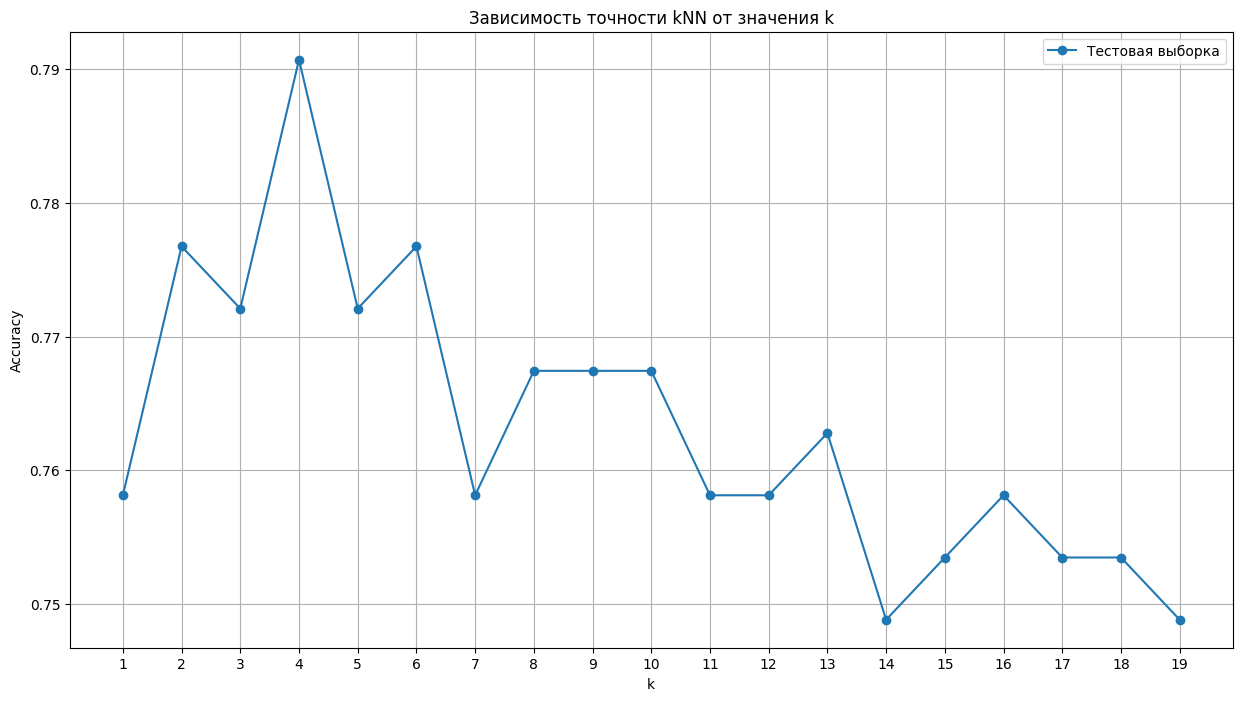

In [27]:
plt.figure(figsize=(15, 8))
plt.plot(k_values, test_accuracy, label="Тестовая выборка", marker="o")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Зависимость точности kNN от значения k")
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()

**Вывод:** С нормализацией максимальный показатель метрики accuracy приблизительно 0.79, что является хорошим результатом, обыгрывающим предыдущие оценки

<!-- Внимание! Здесь находится специальная отметка. Ее нельзя удалять! Ответы на вопросы / выводы для предыдущего пункта(ов) пиши в ячейках выше! -->
<!-- 02a5bc7d6f2e8382a04db099c58ba6d1 -->
**А можем ли мы как-то еще повысить точность модели?**

Как мы видели, параметр $k$ числа соседей является необучаемым т.е. гиперпараметром, который выставляется вручную. Выбор оптимального значения $k$ важен, так как слишком маленькое значение может привести к переобучению, а слишком большое — к недообучению.



Постройте график зависимости точности (`accuracy_score`) от значения $k$ (от 1 до 20) для обучающей и тестовой выборок.

In [28]:
train_accuracy = []
test_accuracy = []

k_values = range(1, 21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, algorithm="brute")
    model.fit(X_scaled_train, y_train)
    y_train_pred = model.predict(X_scaled_train)
    y_test_pred = model.predict(X_scaled_test)
    train_accuracy.append(accuracy_score(y_train, y_train_pred))
    test_accuracy.append(accuracy_score(y_test, y_test_pred))

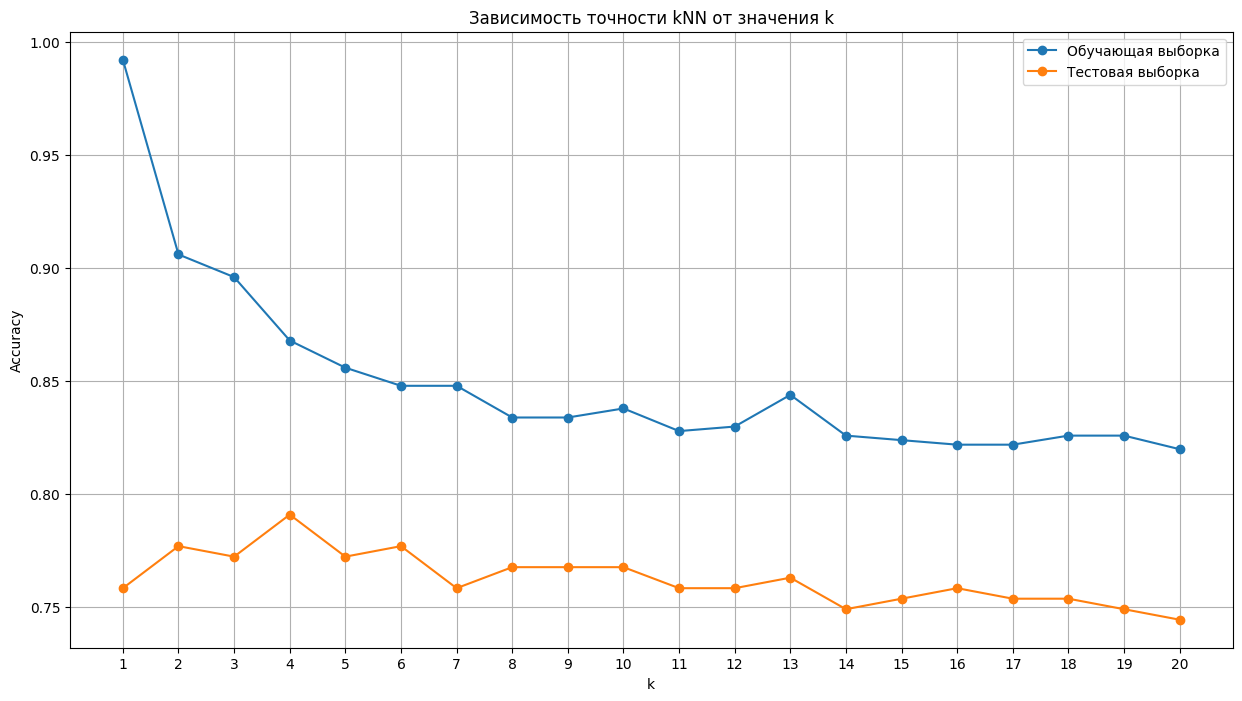

In [29]:
plt.figure(figsize=(15, 8))
plt.plot(k_values, train_accuracy, label="Обучающая выборка", marker="o")
plt.plot(k_values, test_accuracy, label="Тестовая выборка", marker="o")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Зависимость точности kNN от значения k")
plt.legend()
plt.grid(True)
plt.xticks(k_values)
plt.show()

**Вывод:** Для данной задачи наилучшее значение k оказалось низким(в диапазоне от 2 до 4). В этой работе мы исследовали влияние нормировки данных на точность метода kNN и убедились в ее необходимости. Так же заметно, что accuracy выше почти на 0.1 на тренировочных данных по сравнению с тестовыми, что свидетельствует о том, что метод kNN плохо применим к данной задаче